# Dataset Classificação - Breast Cancer Wisconsin (Diagnostic) 
- Disponibilizado pelo UCI Machine Learning Repository e contém informações extraídas de análises de imagens digitalizadas de aspirações com agulha fina (Fine Needle Aspirate – FNA) de massas mamárias. 
- Cada instância representa um exame de tumor de mama, e o objetivo principal do dataset é classificar se um tumor é maligno ou benigno com base em características extraídas dessas imagens. As características são descritas por 30 atributos numéricos contínuos, que representam medidas como raio, textura, perímetro, área, suavidade e outras propriedades que descrevem o núcleo celular.

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score as f1,
    precision_score,
    recall_score
)

## Carregamento dos Dados

In [93]:
# carregamento inicial dos dados
df = pd.read_csv("../data/raw/wdbc.data", encoding='utf-8', header=None)

print(df.head())
print(df.shape)

         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1  0.2750  0.08902  
2  0.

In [94]:
# visualização inicial
df.columns = ['Id', 'Diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2',
            'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3'] 
df.head()

,Id,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [95]:
# visualização das informações principais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  569 non-null    int64  
 1   Diagnosis           569 non-null    object 
 2   radius1             569 non-null    float64
 3   texture1            569 non-null    float64
 4   perimeter1          569 non-null    float64
 5   area1               569 non-null    float64
 6   smoothness1         569 non-null    float64
 7   compactness1        569 non-null    float64
 8   concavity1          569 non-null    float64
 9   concave_points1     569 non-null    float64
 10  symmetry1           569 non-null    float64
 11  fractal_dimension1  569 non-null    float64
 12  radius2             569 non-null    float64
 13  texture2            569 non-null    float64
 14  perimeter2          569 non-null    float64
 15  area2               569 non-null    float64
 16  smoothne

In [96]:
# validando a existencia valores ausentes ou falsos zeros
df.isnull().sum()

Id                    0
Diagnosis             0
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64

In [97]:
# estatísticas descritivas
df.describe(include='all')

,Id,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,5.690000e+02,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.037183e+07,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080


## Separação entre Atributos e Classe Alvo

- **X**: conjunto de atributos (features), que representam as medições clínicas.
- **y**: variável alvo, que indica o diagnóstico do tumor.

A variável alvo foi convertida para valores numéricos, facilitando o treinamento dos modelos.

In [98]:
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

In [99]:
y = y.map({"M": 1, "B": 0})

print(np.bincount(y))

[357 212]


## Divisão dos Dados

In [100]:
#treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#validação cruzada 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Modelos Avaliados

Foram avaliados cinco modelos de aprendizado de máquina:

- Regressão Logística
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Árvore de Decisão
- Random Forest

### 1. Regressão Logística

In [102]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

param_lr = {
    "model__C": [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(pipe_lr, param_lr, cv=cv, scoring="f1", n_jobs=-1)
grid_lr.fit(X_train, y_train)

best_params = grid_lr.best_params_
best_score = grid_lr.best_score_
print(f"Melhores parâmetros LR: {best_params}")
print(f"Melhor F1 (validação): {best_score}")

Melhores parâmetros LR: {'model__C': 0.1}
Melhor F1 (validação): 0.9671455449666695


### 2. SVM

In [103]:
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(class_weight="balanced"))
])

param_svm = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"]
}

grid_svm = GridSearchCV(pipe_svm, param_svm, cv=cv, scoring="f1", n_jobs=-1)
grid_svm.fit(X_train, y_train)

best_params = grid_svm.best_params_
best_score = grid_svm.best_score_
print(f"Melhores parâmetros LR: {best_params}")
print(f"Melhor F1 (validação): {best_score}")

Melhores parâmetros LR: {'model__C': 10, 'model__kernel': 'rbf'}
Melhor F1 (validação): 0.9618581684876126


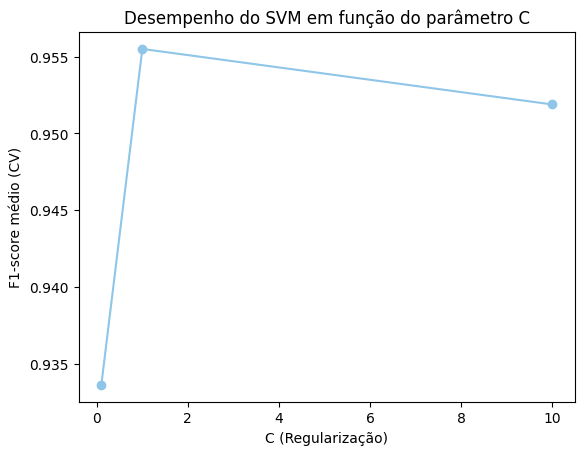

In [104]:
results_svm = pd.DataFrame(grid_svm.cv_results_)

mean_f1_C = results_svm.groupby("param_model__C")["mean_test_score"].mean()

plt.figure()
mean_f1_C.plot(
    marker="o",
    color="#8EC5E8" 
)

plt.title("Desempenho do SVM em função do parâmetro C")
plt.xlabel("C (Regularização)")
plt.ylabel("F1-score médio (CV)")
plt.show()


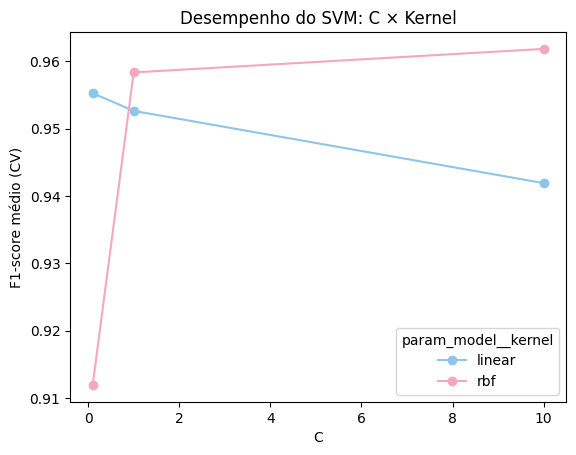

In [105]:

pivot.plot(
    marker="o",
    color=["#8EC5E8", "#F4A7C1"]  # azul pastel, rosa pastel
)

plt.title("Desempenho do SVM: C × Kernel")
plt.xlabel("C")
plt.ylabel("F1-score médio (CV)")
plt.show()


### 3. KNN

In [106]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_knn = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(pipe_knn, param_knn, cv=cv, scoring="f1", n_jobs=-1)
grid_knn.fit(X_train, y_train)

best_params = grid_knn.best_params_
best_score = grid_knn.best_score_
print(f"Melhores parâmetros LR: {best_params}")
print(f"Melhor F1 (validação): {best_score}")

Melhores parâmetros LR: {'model__n_neighbors': 7, 'model__weights': 'uniform'}
Melhor F1 (validação): 0.9604580926320058


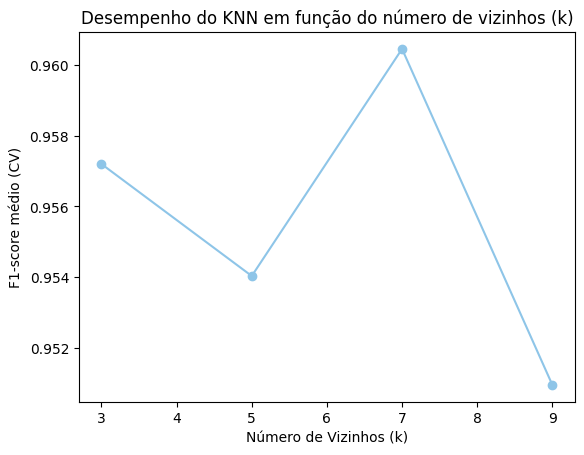

In [ ]:
results_knn = pd.DataFrame(grid_knn.cv_results_)

mean_f1 = results_knn.groupby("param_model__n_neighbors")["mean_test_score"].mean()

plt.figure()
mean_f1.plot(
    marker="o",
    color="#8EC5E8"  
)

plt.title("Desempenho do KNN em função do número de vizinhos (k)")
plt.xlabel("Número de Vizinhos (k)")
plt.ylabel("F1-score médio (CV)")
plt.show()


### 4. Árvore de Decisão 

In [108]:
pipe_dt = Pipeline([
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

param_dt = {
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(pipe_dt, param_dt, cv=cv, scoring="f1", n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_params = grid_dt.best_params_
best_score = grid_dt.best_score_
print(f"Melhores parâmetros LR: {best_params}")
print(f"Melhor F1 (validação): {best_score}")

Melhores parâmetros LR: {'model__max_depth': 5, 'model__min_samples_split': 2}
Melhor F1 (validação): 0.9045610339854063


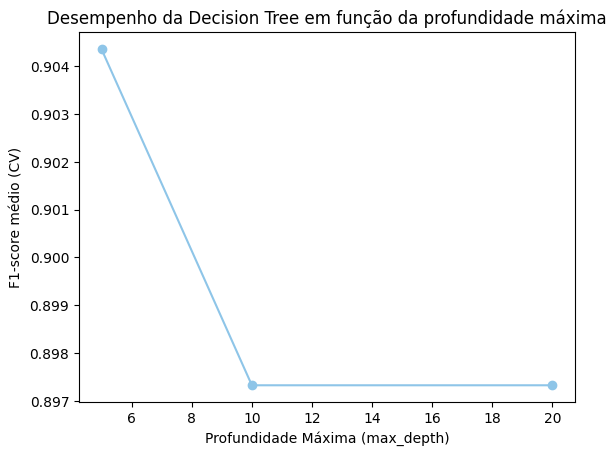

In [109]:
results_dt = pd.DataFrame(grid_dt.cv_results_)

mean_f1_depth = results_dt.groupby("param_model__max_depth")["mean_test_score"].mean()

plt.figure()
mean_f1_depth.plot(
    marker="o",
    color="#8EC5E8"  
)

plt.title("Desempenho da Decision Tree em função da profundidade máxima")
plt.xlabel("Profundidade Máxima (max_depth)")
plt.ylabel("F1-score médio (CV)")
plt.show()


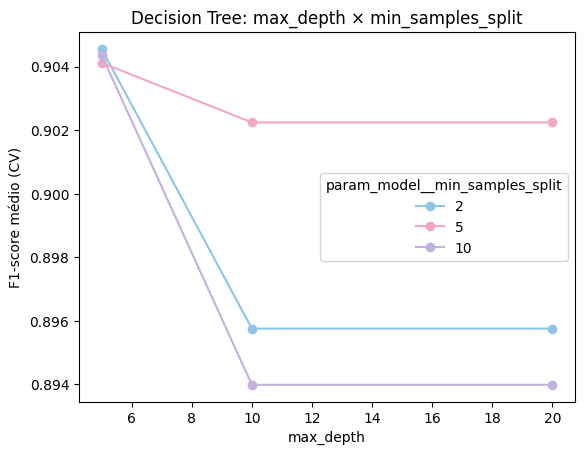

In [ ]:
results_dt = pd.DataFrame(grid_dt.cv_results_)

pivot_dt = results_dt.pivot_table(
    values="mean_test_score",
    index="param_model__max_depth",
    columns="param_model__min_samples_split"
)

pivot_dt.plot(
    marker="o",
    color=["#8EC5E8", "#F4A7C1", "#C3B1E1"]  
)

plt.title("Decision Tree: max_depth × min_samples_split")
plt.xlabel("max_depth")
plt.ylabel("F1-score médio (CV)")
plt.show()


### 5. Random Forest 

In [111]:
pipe_rf = Pipeline([
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])

param_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20]
}

grid_rf = GridSearchCV(pipe_rf, param_rf, cv=cv, scoring="f1", n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_params = grid_rf.best_params_
best_score = grid_rf.best_score_
print(f"Melhores parâmetros LR: {best_params}")
print(f"Melhor F1 (validação): {best_score}")

Melhores parâmetros LR: {'model__max_depth': None, 'model__n_estimators': 200}
Melhor F1 (validação): 0.9520499108734404


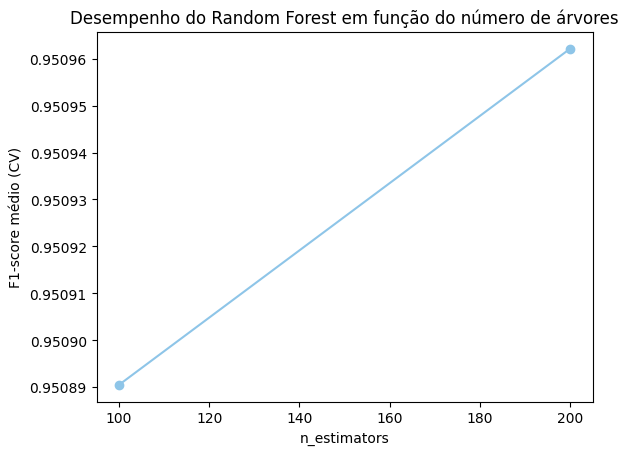

In [112]:
results_rf = pd.DataFrame(grid_rf.cv_results_)

mean_f1_estimators = results_rf.groupby("param_model__n_estimators")["mean_test_score"].mean()

plt.figure()
mean_f1_estimators.plot(
    marker="o",
    color="#8EC5E8"  
)

plt.title("Desempenho do Random Forest em função do número de árvores")
plt.xlabel("n_estimators")
plt.ylabel("F1-score médio (CV)")
plt.show()

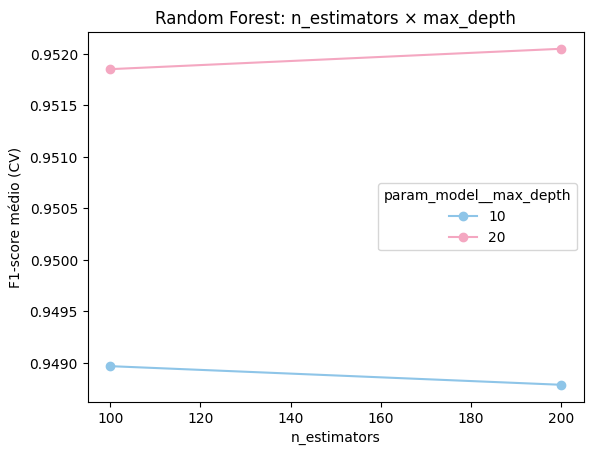

In [113]:
pivot_rf = results_rf.pivot_table(
    values="mean_test_score",
    index="param_model__n_estimators",
    columns="param_model__max_depth"
)

pivot_rf.plot(
    marker="o",
    color=["#8EC5E8", "#F4A7C1", "#C3B1E1"]  
)

plt.title("Random Forest: n_estimators × max_depth")
plt.xlabel("n_estimators")
plt.ylabel("F1-score médio (CV)")
plt.show()

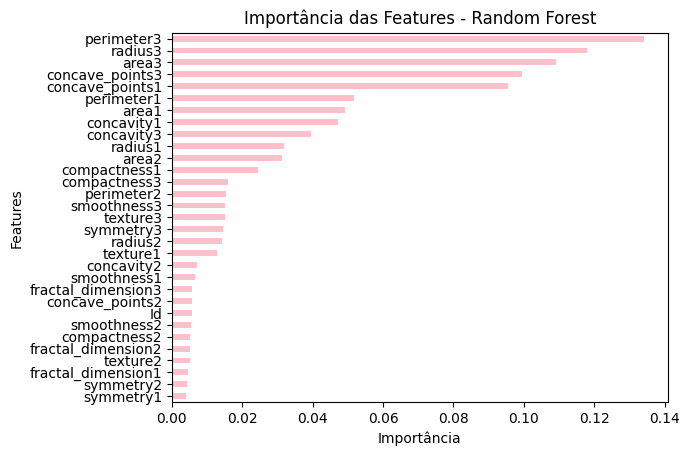

In [114]:
rf_model = grid_rf.best_estimator_.named_steps["model"]

importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
importance_rf.plot(
    kind="barh",
    color="pink"
)

plt.title("Importância das Features - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()


## Resultados 

In [115]:
results_sorted = pd.DataFrame([
    {
        "Modelo": "Logistic Regression",
        "F1 (CV)": grid_lr.best_score_,
        "Hiperparametros": grid_lr.best_params_
    },
    {
        "Modelo": "SVM",
        "F1 (CV)": grid_svm.best_score_,
        "Hiperparametros": grid_svm.best_params_
    },
    {
        "Modelo": "KNN",
        "F1 (CV)": grid_knn.best_score_,
        "Hiperparametros": grid_knn.best_params_
    },
    {
        "Modelo": "Decision Tree",
        "F1 (CV)": grid_dt.best_score_,
        "Hiperparametros": grid_dt.best_params_
    },
    {
        "Modelo": "Random Forest",
        "F1 (CV)": grid_rf.best_score_,
        "Hiperparametros": grid_rf.best_params_
    }
]).sort_values(by="F1 (CV)", ascending=False).reset_index(drop=True)

In [116]:
print("=" * 100)
print("COMPARAÇÃO DE MODELOS - WISCONSIN BREAST CANCER DATASET")
print("=" * 100)

print(f"{'Modelo':<25} {'F1 (CV)':<10} {'Hiperparâmetros'}")
print("-" * 100)

for idx, row in results_sorted.iterrows():
    modelo = row["Modelo"]
    f1_score = row["F1 (CV)"]

    # Ranking simples
    rank = idx + 1

    # Formatar parâmetros
    params = row["Hiperparametros"]
    params_list = []
    if isinstance(params, dict):
        for key, value in params.items():
            param_name = key.replace("model__", "")
            params_list.append(f"{param_name}={value}")
        params_str = " | ".join(params_list)
    else:
        params_str = str(params)

    print(f"{rank:<3} {modelo:<25} {f1_score:.4f}     {params_str}")

print("-" * 100)

# Melhor modelo
best = results_sorted.iloc[0]
print("\nRECOMENDAÇÃO FINAL")
print("-" * 100)
print(f"Modelo recomendado : {best['Modelo']}")
print(f"F1-Score (CV)       : {best['F1 (CV)']:.4f}")
print("Configuração otimizada:")
for key, value in best["Hiperparametros"].items():
    param_name = key.replace("model__", "")
    print(f"  - {param_name}: {value}")

print("=" * 100)


COMPARAÇÃO DE MODELOS - WISCONSIN BREAST CANCER DATASET
Modelo                    F1 (CV)    Hiperparâmetros
----------------------------------------------------------------------------------------------------
1   Logistic Regression       0.9671     C=0.1
2   SVM                       0.9619     C=10 | kernel=rbf
3   KNN                       0.9605     n_neighbors=7 | weights=uniform
4   Random Forest             0.9520     max_depth=None | n_estimators=200
5   Decision Tree             0.9046     max_depth=5 | min_samples_split=2
----------------------------------------------------------------------------------------------------

RECOMENDAÇÃO FINAL
----------------------------------------------------------------------------------------------------
Modelo recomendado : Logistic Regression
F1-Score (CV)       : 0.9671
Configuração otimizada:
  - C: 0.1


In [117]:
best_model = max(
    [grid_lr, grid_svm, grid_knn, grid_dt, grid_rf],
    key=lambda x: x.best_score_
).best_estimator_

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[72  0]
 [ 1 41]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        72
           1       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [118]:
def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    return {
        "Modelo": nome,
        "Matriz de Confusão": confusion_matrix(y_test, y_pred),
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1(y_test, y_pred)
    }

In [119]:
resultados = []

resultados.append(avaliar_modelo(
    "Logistic Regression",
    grid_lr.best_estimator_,
    X_test,
    y_test
))

resultados.append(avaliar_modelo(
    "SVM",
    grid_svm.best_estimator_,
    X_test,
    y_test
))

resultados.append(avaliar_modelo(
    "KNN",
    grid_knn.best_estimator_,
    X_test,
    y_test
))

resultados.append(avaliar_modelo(
    "Decision Tree",
    grid_dt.best_estimator_,
    X_test,
    y_test
))

resultados.append(avaliar_modelo(
    "Random Forest",
    grid_rf.best_estimator_,
    X_test,
    y_test
))


## Avaliação dos Modelos

Os modelos ajustados foram avaliados no conjunto de teste por meio das seguintes métricas:
- Matriz de confusão
- Acurácia
- Precisão
- Recall
- F1-score

In [137]:
rosa_pastel = "#F4A7C1"

def plot_bar_metric(df, metric, title):
    df_plot = df.sort_values(by=metric, ascending=False)

    plt.figure()
    bars = plt.bar(df_plot["Modelo"], df_plot[metric], color=rosa_pastel)

    plt.title(title)
    plt.xlabel("Modelo")
    plt.ylabel(metric)
    plt.xticks(rotation=45)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

    plt.ylim(0, 1.05)
    plt.show()


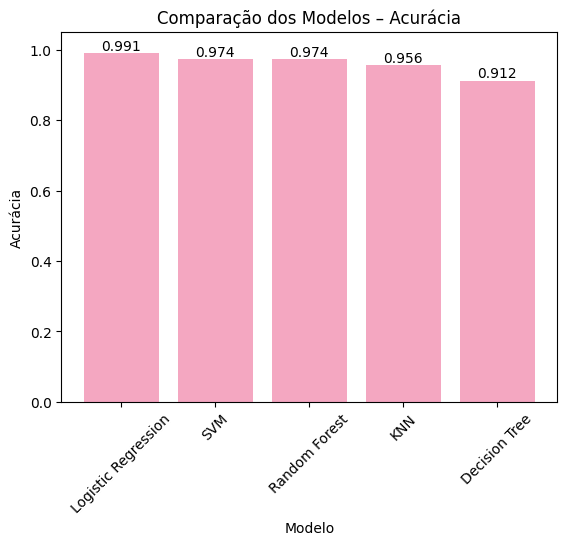

In [138]:
plot_bar_metric(
    df_resultados,
    "Acurácia",
    "Comparação dos Modelos – Acurácia"
)

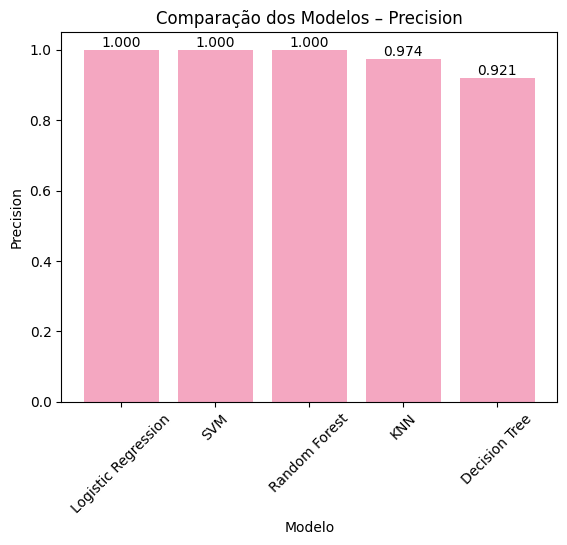

In [139]:
plot_bar_metric(
    df_resultados,
    "Precision",
    "Comparação dos Modelos – Precision"
)

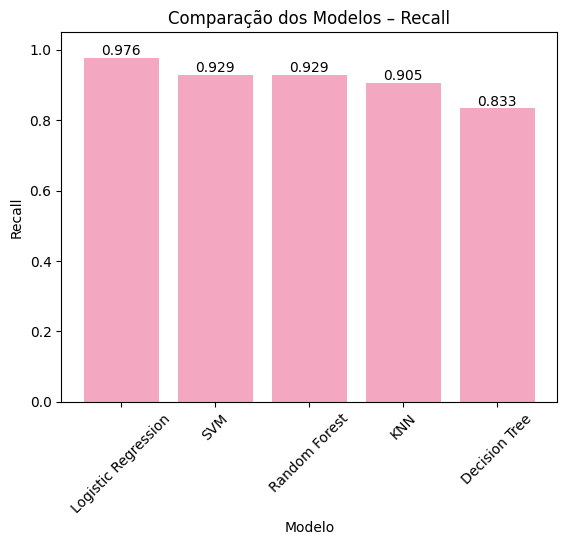

In [140]:
plot_bar_metric(
    df_resultados,
    "Recall",
    "Comparação dos Modelos – Recall"
)

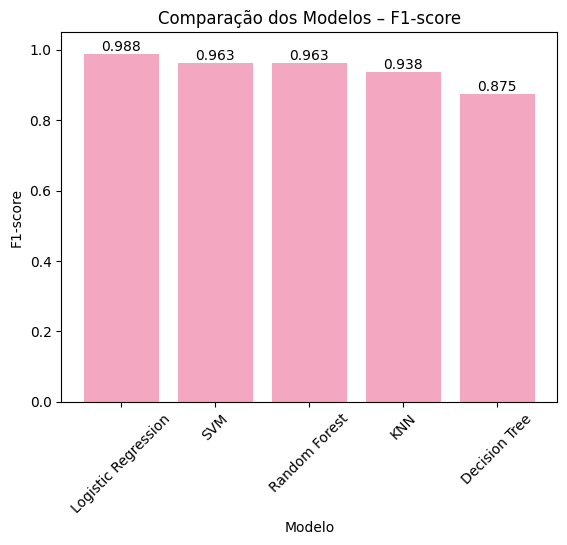

In [141]:
plot_bar_metric(
    df_resultados,
    "F1-score",
    "Comparação dos Modelos – F1-score"
)

In [120]:
df_resultados = pd.DataFrame(resultados)

df_resultados

,Modelo,Matriz de Confusão,Acurácia,Precision,Recall,F1-score
0,Logistic Regression,"[[72, 0], [1, 41]]",0.991228,1.000000,0.976190,0.987952
1,SVM,"[[72, 0], [3, 39]]",0.973684,1.000000,0.928571,0.962963
2,KNN,"[[71, 1], [4, 38]]",0.956140,0.974359,0.904762,0.938272
3,Decision Tree,"[[69, 3], [7, 35]]",0.912281,0.921053,0.833333,0.875000
4,Random Forest,"[[72, 0], [3, 39]]",0.973684,1.000000,0.928571,0.962963


In [121]:
df_resultados.sort_values(by="F1-score", ascending=False)

,Modelo,Matriz de Confusão,Acurácia,Precision,Recall,F1-score
0,Logistic Regression,"[[72, 0], [1, 41]]",0.991228,1.000000,0.976190,0.987952
1,SVM,"[[72, 0], [3, 39]]",0.973684,1.000000,0.928571,0.962963
4,Random Forest,"[[72, 0], [3, 39]]",0.973684,1.000000,0.928571,0.962963
2,KNN,"[[71, 1], [4, 38]]",0.956140,0.974359,0.904762,0.938272
3,Decision Tree,"[[69, 3], [7, 35]]",0.912281,0.921053,0.833333,0.875000


In [122]:
for r in resultados:
    print(f"\nModelo: {r['Modelo']}")
    print("Matriz de Confusão:")
    print(r["Matriz de Confusão"])


Modelo: Logistic Regression
Matriz de Confusão:
[[72  0]
 [ 1 41]]

Modelo: SVM
Matriz de Confusão:
[[72  0]
 [ 3 39]]

Modelo: KNN
Matriz de Confusão:
[[71  1]
 [ 4 38]]

Modelo: Decision Tree
Matriz de Confusão:
[[69  3]
 [ 7 35]]

Modelo: Random Forest
Matriz de Confusão:
[[72  0]
 [ 3 39]]


In [123]:
import sys
!{sys.executable} -m pip install matplotlib

In [124]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(4, 4))

    # Criar matriz de cores:
    # 1 = acerto (diagonal), 0 = erro
    color_matrix = np.zeros_like(cm)
    np.fill_diagonal(color_matrix, 1)

    # Colormap pastel:
    # 0 -> erro (rosa claro)
    # 1 -> acerto (verde pastel)
    cmap = ListedColormap(["#f7c6c7", "#c7e9c0"])

    plt.imshow(color_matrix, cmap=cmap)

    classes = ["Benigno", "Maligno"]
    plt.xticks([0, 1], classes)
    plt.yticks([0, 1], classes)

    plt.title(f"Matriz de Confusão - {model_name}")

    # valores dentro da matriz
    for i in range(2):
        for j in range(2):
            plt.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
                fontsize=12,
                color="black"
            )

    plt.xlabel("Classe Predita")
    plt.ylabel("Classe Real")
    plt.tight_layout()
    plt.show()

## Matrizes de Confusão

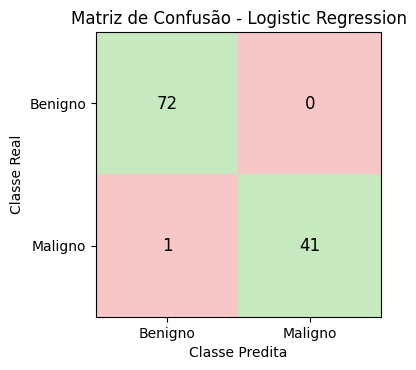

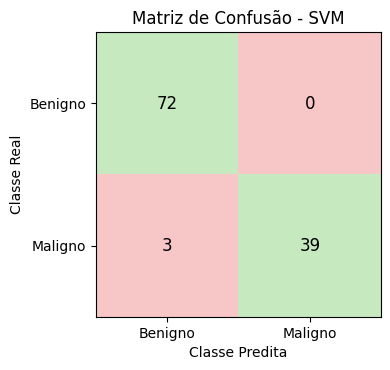

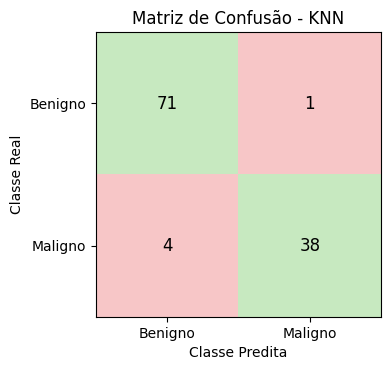

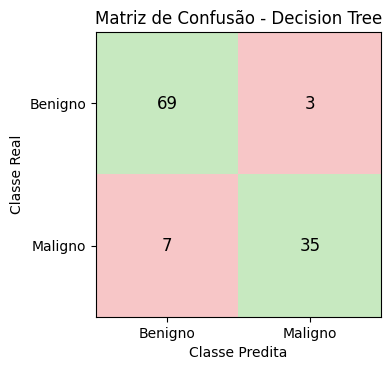

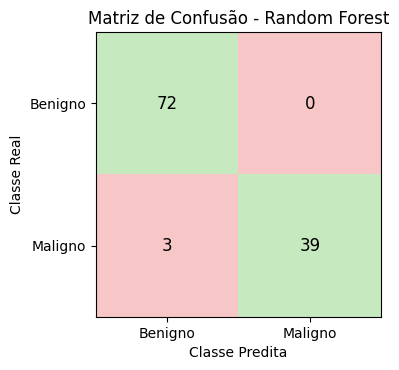

In [125]:
for r in resultados:
    plot_confusion_matrix(
        r["Matriz de Confusão"],
        r["Modelo"]
    )

## Explicabilidade dos Modelos

Com Regressão Logística, os coeficientes do modelo indicam a influência de cada atributo na probabilidade de um tumor ser classificado como maligno.

Coeficientes positivos aumentam a probabilidade da classe maligna, enquanto coeficientes negativos reduzem essa probabilidade.

In [126]:
feature_names = X.columns

best_lr = grid_lr.best_estimator_

coef_lr = pd.Series(
    best_lr.named_steps["model"].coef_[0],
    index=feature_names
).sort_values(key=abs, ascending=False)

coef_lr.head(10)

texture3           0.627994
radius3            0.505012
radius2            0.481964
perimeter3         0.457838
symmetry3          0.454356
area3              0.451110
concave_points3    0.446922
concave_points1    0.445529
texture1           0.425488
concavity3         0.376499
dtype: float64

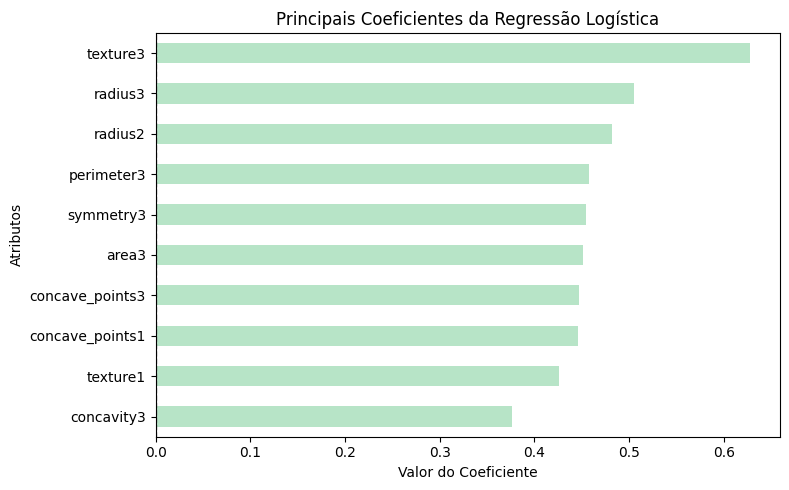

In [127]:
# Selecionar os 10 coeficientes mais importantes
top_coef = coef_lr.head(10)

plt.figure(figsize=(8, 5))

# Gráfico de barras horizontais
top_coef.sort_values().plot(
    kind="barh",
    color="#b7e4c7"
)

plt.title("Principais Coeficientes da Regressão Logística")
plt.xlabel("Valor do Coeficiente")
plt.ylabel("Atributos")
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [128]:
coef_lr_all = pd.Series(
    best_lr.named_steps["model"].coef_[0],
    index=feature_names
)

coef_lr_all[coef_lr_all < 0].sort_values().head(10)


compactness2         -0.279844
fractal_dimension2   -0.264024
fractal_dimension1   -0.188695
symmetry2            -0.136937
concavity2           -0.047652
texture2             -0.042823
dtype: float64

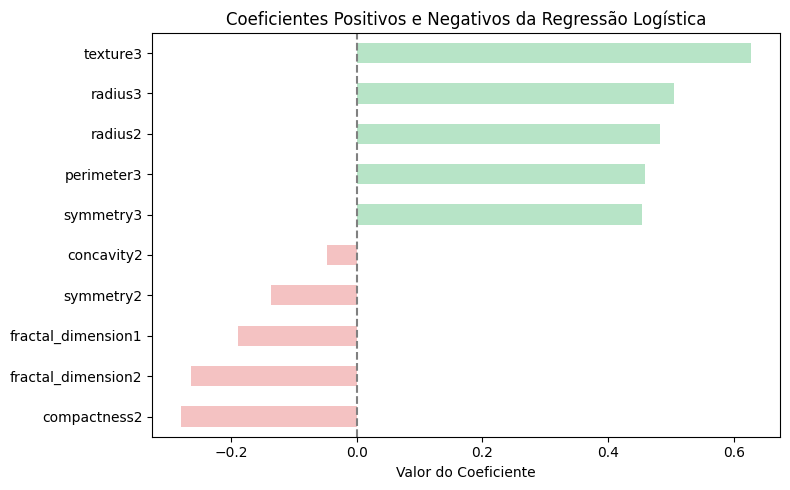

In [129]:
top_pos = coef_lr_all.sort_values(ascending=False).head(5)
top_neg = coef_lr_all.sort_values().head(5)

coef_plot = pd.concat([top_neg, top_pos])

colors = ["#b7e4c7" if v > 0 else "#f4c2c2" for v in coef_plot]

plt.figure(figsize=(8, 5))
coef_plot.sort_values().plot(kind="barh", color=colors)
plt.axvline(0, color="gray", linestyle="--")
plt.title("Coeficientes Positivos e Negativos da Regressão Logística")
plt.xlabel("Valor do Coeficiente")
plt.tight_layout()
plt.show()

In [130]:
best_lr = grid_lr.best_estimator_

X_train_scaled = best_lr.named_steps["scaler"].transform(X_train)
X_test_scaled = best_lr.named_steps["scaler"].transform(X_test)